In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df_orders = pd.read_csv("olist_orders_dataset.csv")
df_customers = pd.read_csv("olist_customers_dataset.csv")
df_items = pd.read_csv("olist_order_items_dataset.csv")

In [3]:
df_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [4]:
df_orders.shape

(99441, 8)

In [5]:
df_orders.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='str')

In [6]:
df_orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [7]:
df_orders.dtypes

order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object

In [8]:
df_orders["order_purchase_timestamp"] = pd.to_datetime(df_orders["order_purchase_timestamp"], errors="coerce")

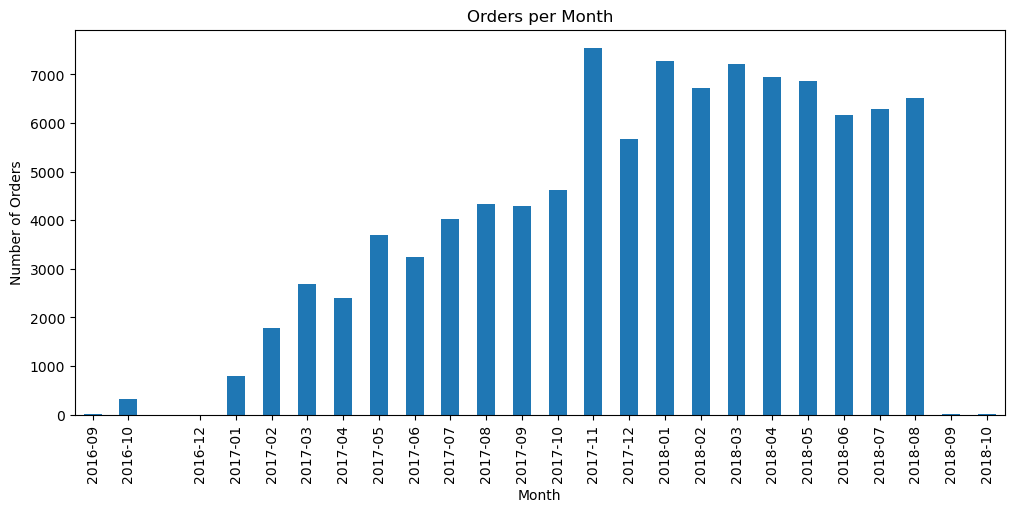

In [9]:
orders_per_month = df_orders["order_purchase_timestamp"].dt.to_period("M").value_counts().sort_index()
orders_per_month.plot(kind="bar", figsize=(12, 5))
plt.title("Orders per Month")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.show()

In [17]:
order_per_customer = df_orders.groupby('customer_id')['order_id'].count()
one_time_customers = order_per_customer[order_per_customer == 1].sum()
print(f"Number of one-time customers: {one_time_customers}")

Number of one-time customers: 99441


In [18]:
order_per_customer.value_counts().sort_index()

order_id
1    99441
Name: count, dtype: int64

In [20]:
df_customers.shape

(99441, 5)

In [21]:
df_items.shape

(112650, 7)

### Notes
- The orders dataset has 99,441 rows and 8 columns.
- `order_purchase_timestamp` was originally stored as text and has been converted to datetime.
- Missing values appear mostly in delivery-related date columns, while `order_id`, `customer_id`, and purchase timestamp have no missing values.
- Monthly order volume rises through 2017 and stays much higher during most of 2018.
- Grouping by `customer_id`, every customer appears to have exactly one order in this dataset.

In [22]:
reference_date = df_orders['order_purchase_timestamp'].max()
reference_date

Timestamp('2018-10-17 17:30:18')

In [23]:
last_order = df_orders.groupby("customer_id")["order_purchase_timestamp"].max()

last_order

customer_id
00012a2ce6f8dcda20d059ce98491703   2017-11-14 16:08:26
000161a058600d5901f007fab4c27140   2017-07-16 09:40:32
0001fd6190edaaf884bcaf3d49edf079   2017-02-28 11:06:43
0002414f95344307404f0ace7a26f1d5   2017-08-16 13:09:20
000379cdec625522490c315e70c7a9fb   2018-04-02 13:42:17
                                           ...        
fffecc9f79fd8c764f843e9951b11341   2018-03-29 16:59:26
fffeda5b6d849fbd39689bb92087f431   2018-05-22 13:36:02
ffff42319e9b2d713724ae527742af25   2018-06-13 16:57:05
ffffa3172527f765de70084a7e53aae8   2017-09-02 11:53:32
ffffe8b65bbe3087b653a978c870db99   2017-09-29 14:07:03
Name: order_purchase_timestamp, Length: 99441, dtype: datetime64[us]

In [24]:
inactive_customers = last_order[last_order < reference_date - pd.Timedelta(days=90)]
print(f"Number of inactive customers: {inactive_customers.shape[0]}")

Number of inactive customers: 89912


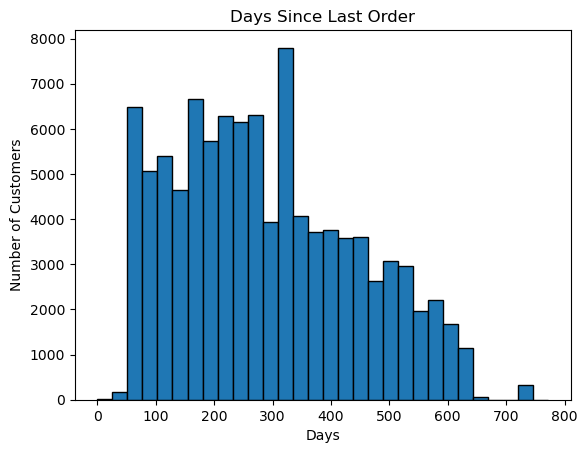

In [29]:
days_since_last_order = (reference_date - last_order).dt.days
plt.hist(days_since_last_order, bins=30, edgecolor='black')
plt.title("Days Since Last Order")
plt.xlabel("Days")
plt.ylabel("Number of Customers")
plt.show()


In [30]:
# labeled as churn = 1 and not churn = 0
churn_labels = (last_order < reference_date - pd.Timedelta(days=90)).astype(int)
churn_labels.value_counts()


order_purchase_timestamp
1    89912
0     9529
Name: count, dtype: int64

In [32]:
# label customers as churn = 1 if days since last order > 90, else 0
churn_labels = (days_since_last_order > 90).astype(int)
churn_labels.value_counts()

order_purchase_timestamp
1    89652
0     9789
Name: count, dtype: int64

In [33]:
churn_rate = churn_labels.mean() * 100
print(f"Churn rate: {churn_rate:.2f}%")

Churn rate: 90.16%


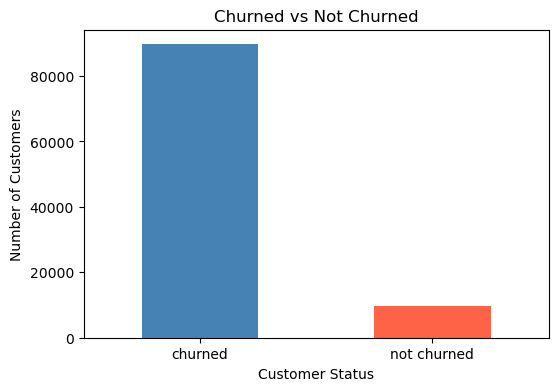

In [34]:
churn_counts = churn_labels.map({0: "not churned", 1: "churned"}).value_counts()

churn_counts.plot(kind="bar", figsize=(6, 4), color=["steelblue", "tomato"])
plt.title("Churned vs Not Churned")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

In [ ]:

# The churn rate is 90.16%, indicating that the vast majority of customers (90,000+) have not made a purchase in over 90 days.
# This high churn rate suggests poor customer retention, likely because each customer in this dataset has only made a single purchase.
# A retention strategy should focus on encouraging repeat purchases through loyalty programs or targeted re-engagement campaigns.